# Planning Algorithms

Notebook này trình bày quy trình thực hành trực tiếp cho nhóm **Planning Algorithms** trên bài toán **Grid-world Navigation 8x8**. Mục tiêu không chỉ là chạy thuật toán, mà còn hiểu rõ cách mỗi thuật toán được xây dựng từ **Bellman equations**, cách khởi tạo model, cách gọi thuật toán, cách lấy metrics, đánh giá kết quả và trực quan hóa value function/policy thu được.

Trong Reinforcement Learning, **Planning Algorithms** được sử dụng khi agent biết trước mô hình đầy đủ của môi trường, tức là biết:

$$
P(s' \mid s,a)
$$

và

$$
r(s,a,s')
$$

Trong đó:

- $s$ là trạng thái hiện tại.
- $a$ là hành động agent chọn.
- $s'$ là trạng thái kế tiếp.
- $P(s' \mid s,a)$ là xác suất chuyển từ $s$ sang $s'$ khi thực hiện hành động $a$.
- $r(s,a,s')$ là reward nhận được khi chuyển từ $s$ sang $s'$.

Điểm khác biệt quan trọng giữa **Planning** và **Learning** là Planning không cần học bằng cách thử-sai qua nhiều episode trong môi trường. Thay vào đó, vì đã biết model của MDP, agent có thể tính toán trực tiếp expected return thông qua các Bellman equations.

MDP của bài toán được mô tả bởi:

$$
\mathcal{M} = (\mathcal{S}, \mathcal{A}, P, r, \gamma)
$$

Trong đó:

- $\mathcal{S}$: tập trạng thái.
- $\mathcal{A}$: tập hành động.
- $P$: transition model.
- $r$: reward function.
- $\gamma$: discount factor, dùng để cân bằng giữa reward hiện tại và reward tương lai.

Với Planning Algorithms, thao tác cốt lõi thường là tính kỳ vọng trên toàn bộ các trạng thái kế tiếp có thể xảy ra:

$$
\sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V(s')\right]
$$

Biểu thức này trả lời câu hỏi: nếu agent đang ở trạng thái $s$, chọn hành động $a$, rồi sau đó tiếp tục tối ưu hoặc đi theo một policy nào đó, thì expected return nhận được là bao nhiêu?

Trong project này, Planning environment cung cấp model thông qua API:

```python
env.get_transitions(state, action)
```

Hàm này cho biết các trạng thái kế tiếp có thể xảy ra, xác suất tương ứng, reward và trạng thái kết thúc nếu có. Đây là điểm quan trọng giúp Planning Algorithms có thể tính toán Bellman backup trực tiếp.

Notebook này tập trung vào bốn thuật toán Planning chính:

1. **Policy Evaluation**: đánh giá một policy cố định $\pi$ bằng cách tính state-value function $V^\pi(s)$.
2. **Policy Iteration**: tìm policy tối ưu bằng cách lặp giữa hai bước: đánh giá policy hiện tại và cải thiện policy theo hướng greedy.
3. **Value Iteration**: tìm trực tiếp optimal value function $V^*(s)$ bằng Bellman optimality backup, sau đó trích xuất optimal policy.
4. **Linear Programming Planner**: biểu diễn bài toán tìm $V^*$ dưới dạng một bài toán tối ưu tuyến tính dựa trên Bellman optimality inequalities.

Về mặt thực nghiệm, notebook sẽ đi theo luồng:

1. Tạo môi trường Grid-world 8x8.
2. Khởi tạo từng thuật toán Planning.
3. Gọi `.run()` để chạy thuật toán.
4. Lấy value function, policy và metrics.
5. Đánh giá kết quả bằng các metrics như residual, value error, policy agreement và runtime.
6. Trực quan hóa value heatmap, policy arrows và convergence curves nếu có helper tương ứng.

Vai trò của nhóm Planning trong toàn bộ project là rất quan trọng vì nó cung cấp các nghiệm/baseline có độ tin cậy cao. Cụ thể:

- **Policy Evaluation** đóng vai trò baseline cho các thuật toán prediction như TD(0) và TD($\lambda$).
- **Value Iteration** đóng vai trò baseline cho các thuật toán control như SARSA và Q-learning.
- **Policy Iteration** và **Linear Programming Planner** được so sánh với Value Iteration để kiểm tra tính nhất quán của nghiệm tối ưu.

Do đó, phần Planning không chỉ giúp hiểu các thuật toán model-based, mà còn là nền tảng để đánh giá các thuật toán Learning ở notebook tiếp theo.


## Thiết lập 

### Thiết lập project root

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/home/phat/AI_Project/Reinforcement-Learning')

### Import thư viện, model, metrics và visualization

In [2]:
from pathlib import Path
from time import perf_counter

from envs.planning_grid_world import PlanningGridWorld
from agents.planning import (
    PolicyEvaluation,
    PolicyIteration,
    ValueIteration,
    LinearProgrammingPlanner,
)
from utils.metrics import mean_squared_error, max_abs_error, policy_agreement
from utils.visualization import (
    plot_grid_world_layout,
    plot_value_heatmap,
    plot_policy_arrows,
    plot_policy_changes,
    plot_bellman_residual,
    plot_comparison_bar,
)

NOTEBOOK_FIGURE_DIR = PROJECT_ROOT / "report" / "figures" / "planning"
NOTEBOOK_VERBOSE = 2
NOTEBOOK_LOG_INTERVAL = 100

NOTEBOOK_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_FIGURE_DIR

PosixPath('/home/phat/AI_Project/Reinforcement-Learning/report/figures/planning')

### Helper functions cho notebook

In [3]:
def show_metrics(metrics, keys=None):
    if metrics is None:
        print("No metrics available.")
        return
    selected = metrics if keys is None else {key: metrics.get(key) for key in keys}
    for key, value in selected.items():
        print(f"{key}: {value}")

## Thiết kế Grid-world 8x8

Trong project này, môi trường được sử dụng là **Grid-world Navigation 8x8**, một môi trường rời rạc đơn giản nhưng rất phù hợp để minh họa các khái niệm cốt lõi trong Reinforcement Learning, đặc biệt là **Markov Decision Process (MDP)** và các **Planning Algorithms**.

Mỗi trạng thái trong môi trường được biểu diễn bởi một ô có tọa độ:

$$
s = (row, col)
$$

Agent có thể thực hiện một trong bốn hành động cơ bản:

$$
\mathcal{A} = \{up, down, left, right\}
$$

Trong bố cục Grid-world:

- **Start state** là vị trí khởi đầu của agent.
- **Goal states** là các trạng thái đích; khi agent đi tới đây, episode kết thúc với phần thưởng dương.
- **Trap states** là các trạng thái bất lợi; khi agent rơi vào đây, episode kết thúc với phần thưởng âm.
- **Wall states** là các ô chướng ngại; agent không thể đi xuyên qua.
- **Step reward** được áp dụng cho mỗi bước di chuyển, nhằm khuyến khích agent tìm đường đi hiệu quả.

Về mặt hình thức, Grid-world được mô hình hóa như một MDP:

$$
\mathcal{M} = (\mathcal{S}, \mathcal{A}, P, r, \gamma)
$$

trong đó:

- $\mathcal{S}$ là tập trạng thái.
- $\mathcal{A}$ là tập hành động.
- $P(s' \mid s,a)$ là xác suất chuyển trạng thái.
- $r(s,a,s')$ là hàm phần thưởng.
- $\gamma$ là hệ số chiết khấu.

Điểm quan trọng của môi trường `PlanningGridWorld` là agent có thể truy cập trực tiếp mô hình chuyển trạng thái thông qua API:

```python
env.get_transitions(state, action)
```

Điều này cho phép các thuật toán Planning tính toán Bellman backup trực tiếp từ model, thay vì phải học thông qua tương tác mẫu như các thuật toán Learning.

Trong notebook này, môi trường sẽ được khởi tạo với cấu hình mặc định của project, nhằm đảm bảo toàn bộ các thuật toán Planning được đánh giá trên cùng một bài toán chuẩn.


In [4]:
planning_env = PlanningGridWorld()
planning_env

In [5]:
print("Grid size:", planning_env.grid_size)
print("Start state:", planning_env.start_state)
print("Goal states:", planning_env.goal_states)
print("Trap states:", planning_env.trap_states)
print("Wall states:", planning_env.wall_states)
print("Actions:", planning_env.actions)
print("Reward config:", planning_env.reward_config)
print("Gamma:", planning_env.gamma)
print("Number of states:", planning_env.num_states())

Grid size: (8, 8)
Start state: (0, 0)
Goal states: {(7, 7)}
Trap states: {(4, 4), (3, 3)}
Wall states: {(2, 3), (5, 5), (2, 2)}
Actions: ('up', 'down', 'left', 'right')
Reward config: {'step': -1.0, 'goal': 10.0, 'trap': -10.0, 'wall': -1.0}
Gamma: 0.99
Number of states: 61


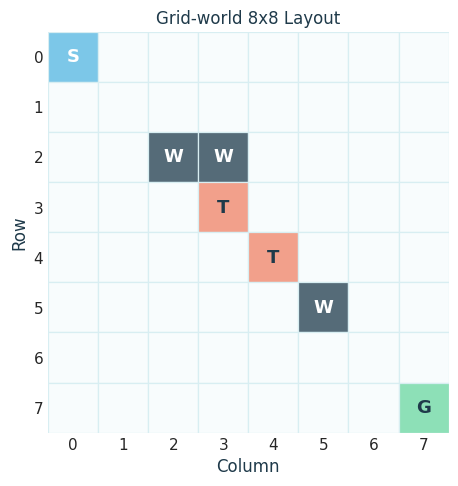

(<Figure size 640x520 with 1 Axes>,
 <Axes: title={'center': 'Grid-world 8x8 Layout'}, xlabel='Column', ylabel='Row'>)

In [6]:
layout_path = NOTEBOOK_FIGURE_DIR / "grid_world_layout.png"
plot_grid_world_layout(
    planning_env,
    title="Grid-world 8x8 Layout",
    save_path=layout_path,
    show=True,
)

**Nhận xét về bố cục Grid-world**

Hình trên cho thấy trực quan cấu trúc của môi trường Grid-world 8x8 được sử dụng trong project. Agent bắt đầu từ ô **Start (S)** và cần tìm đường đi tới ô **Goal (G)**, đồng thời tránh các ô **Trap (T)** và không thể đi xuyên qua các ô **Wall (W)**.

Việc trực quan hóa bố cục môi trường có ý nghĩa quan trọng vì nó giúp giải thích trực giác của value function và policy ở các phần sau. Cụ thể:

- Các trạng thái gần Goal thường có giá trị cao hơn.
- Các trạng thái gần Trap thường có giá trị thấp hơn.
- Các Wall làm thay đổi cấu trúc đường đi tối ưu.
- Policy tối ưu về sau sẽ phản ánh cách agent di chuyển quanh các chướng ngại để đến Goal hiệu quả nhất.

Do đó, phần trực quan hóa Grid-world là bước khởi đầu cần thiết trước khi đi vào từng thuật toán Planning cụ thể.

## Xây dựng và chạy các thuật toán Planning

Trong phần này, ta sẽ lần lượt xây dựng và chạy bốn thuật toán thuộc nhóm **Planning Algorithms** trên cùng một môi trường Grid-world 8x8:

1. **Policy Evaluation**
2. **Policy Iteration**
3. **Value Iteration**
4. **Linear Programming Planner**

### Policy Evaluation

**Policy Evaluation** là bài toán đánh giá chất lượng của một policy cố định $\pi$. Nói cách khác, ta giả sử agent đã có sẵn một chiến lược hành động, sau đó cần tính xem nếu agent luôn hành động theo policy đó thì mỗi state có giá trị kỳ vọng là bao nhiêu.

Giá trị cần tính là **state-value function**:

$$
V^\pi(s) = \mathbb{E}_\pi\left[G_t \mid S_t = s\right]
$$

Trong đó:

- $V^\pi(s)$ là expected return khi bắt đầu từ state $s$ và đi theo policy $\pi$.
- $G_t$ là return từ thời điểm $t$.
- Kỳ vọng $\mathbb{E}_\pi$ được lấy theo policy $\pi$ và dynamics của môi trường.

Vì Planning environment biết đầy đủ model $P(s' \mid s,a)$ và $r(s,a,s')$, ta có thể tính $V^\pi$ bằng **Bellman Expectation Equation**:

$$
V^\pi(s) = \sum_a \pi(a \mid s) \sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V^\pi(s')\right]
$$

Công thức trên nói rằng giá trị của state $s$ bằng kỳ vọng trên tất cả action mà policy có thể chọn, và trên tất cả next state mà môi trường có thể chuyển tới.

Trong project này, nếu không truyền policy vào `PolicyEvaluation`, class sẽ dùng **uniform random policy** mặc định. Điều này có nghĩa là tại mỗi state không kết thúc, agent chọn các action hợp lệ với xác suất bằng nhau.

Policy Evaluation **không tìm policy tối ưu**. Nó chỉ trả lời câu hỏi: nếu agent đi theo policy $\pi$ đã cho, thì mỗi state tốt hay xấu đến mức nào?

Quy trình thực hiện trong notebook:

1. Khởi tạo `PolicyEvaluation`.
2. Gọi `.run()` để thực hiện iterative Bellman expectation backup.
3. Lấy value function $V^\pi$.
4. Lấy metrics hội tụ như residual, số iterations và số Bellman backups.
5. Trực quan hóa $V^\pi$ bằng heatmap.
6. Trực quan hóa Bellman residual để quan sát quá trình hội tụ.


In [7]:
policy_evaluator = PolicyEvaluation(
    env=planning_env,
    policy=None,
    theta=1e-6,
    max_iterations=1000,
    verbose=NOTEBOOK_VERBOSE,
    log_interval=NOTEBOOK_LOG_INTERVAL,
)

start_time = perf_counter()
pe_result = policy_evaluator.run()
pe_runtime = perf_counter() - start_time

pe_values = policy_evaluator.get_value_function()
pe_policy = policy_evaluator.get_policy()
pe_metrics = policy_evaluator.get_metrics()
pe_metrics["notebook_runtime_sec"] = pe_runtime

[PolicyEvaluation] Convergence progress
  iter   | residual   | backups
  ------ | ---------- | -------
     100 |  1.325e-01 |    5800
     200 |  1.066e-02 |   11600
     300 |  8.496e-04 |   17400
     400 |  6.772e-05 |   23200
     500 |  5.398e-06 |   29000
     567 |  9.915e-07 |   32886


In [8]:
sample_state = planning_env.start_state

print("Sample state:", sample_state)
print("Policy at sample state:")

for action, prob in pe_policy[sample_state].items():
    print(f"  {action}: {prob:.3f}")

print("Sum of action probabilities:", sum(pe_policy[sample_state].values()))

Sample state: (0, 0)
Policy at sample state:
  up: 0.250
  down: 0.250
  left: 0.250
  right: 0.250
Sum of action probabilities: 1.0


In [9]:
show_metrics(pe_metrics, keys=[
    "status",
    "iterations",
    "final_bellman_residual",
    "bellman_backups",
    "notebook_runtime_sec",
])

print("Residual < theta:", pe_metrics["final_bellman_residual"] < pe_metrics["theta"])

status: converged
iterations: 567
final_bellman_residual: 9.914539589317428e-07
bellman_backups: 32886
notebook_runtime_sec: 0.27967520099991816
Residual < theta: True


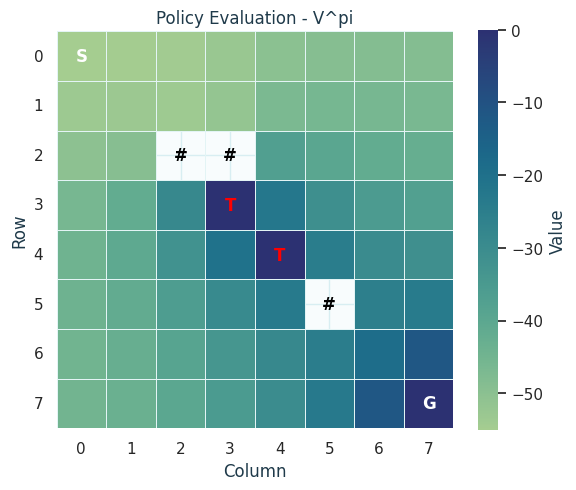

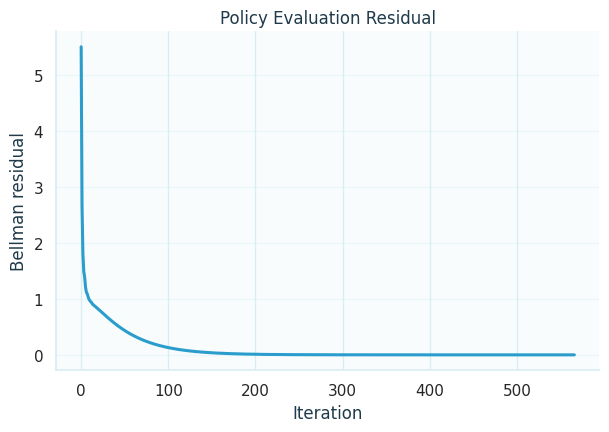

In [15]:
pe_value_path = NOTEBOOK_FIGURE_DIR / "policy_evaluation_value_heatmap.png"
pe_residual_path = NOTEBOOK_FIGURE_DIR / "policy_evaluation_residual.png"

plot_value_heatmap(
    pe_values,
    planning_env,
    "Policy Evaluation - V^pi",
    save_path=pe_value_path,
    show=True,
)

plot_bellman_residual(
    pe_metrics["bellman_residuals"],
    "Policy Evaluation Residual",
    save_path=pe_residual_path,
    show=True,
);

**Nhận xét Policy Evaluation:**

Kết quả cho thấy `PolicyEvaluation` đã hội tụ thành công. Thuật toán dừng tại iteration 567 với:

$$
\text{final\_bellman\_residual} = 9.915 \times 10^{-7} < \theta = 10^{-6}
$$

Điều này cho thấy value function thu được đã gần đạt fixed point của Bellman Expectation Equation:

$$
V^\pi = T^\pi V^\pi
$$

Policy đang được đánh giá là **uniform random policy**. Tại start state $(0, 0)$, bốn hành động `up`, `down`, `left`, `right` đều có xác suất 0.25, tức là:

$$
\pi(a \mid s) = 0.25
$$

Vì vậy, $V^\pi$ trong heatmap phản ánh chất lượng của một agent hành động ngẫu nhiên, không phải agent tối ưu.

Trong heatmap, phần lớn state có value âm. Điều này hợp lý vì agent ngẫu nhiên có thể đi lòng vòng, chịu step cost qua nhiều bước và có khả năng rơi vào Trap. Các state dễ dẫn tới Goal hơn có value cao hơn, trong khi các state gần Trap hoặc khó tiếp cận Goal có value thấp hơn.

Biểu đồ Bellman residual giảm dần về gần 0, cho thấy quá trình Bellman expectation backup hội tụ ổn định. Kết quả này sẽ được dùng như baseline cho các thuật toán prediction như TD(0) và TD($\lambda$) ở phần Learning Algorithms.


### Policy Iteration

**Policy Iteration** là thuật toán tìm policy tối ưu bằng cách lặp lại hai bước: **Policy Evaluation** và **Policy Improvement**. Nếu Policy Evaluation chỉ đánh giá một policy cố định $\pi$, thì Policy Iteration sử dụng kết quả đánh giá đó để cải thiện policy, từ đó tiến dần đến policy tối ưu $\pi^*$.

Mục tiêu của thuật toán là tìm:

$$
\pi^*(s)
$$

và value function tương ứng:

$$
V^*(s)
$$

Trong đó:

- $\pi^*(s)$ là hành động tối ưu tại state $s$.
- $V^*(s)$ là expected return tối đa có thể đạt được khi bắt đầu từ state $s$.
- Policy tối ưu là policy không thể được cải thiện thêm bằng bước greedy improvement.

Policy Iteration gồm hai bước chính.

**Bước 1: Policy Evaluation**

Với policy hiện tại $\pi_k$, thuật toán tính value function $V^{\pi_k}(s)$ bằng Bellman Expectation Equation:

$$
V^{\pi_k}(s) = \sum_a \pi_k(a \mid s) \sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V^{\pi_k}(s')\right]
$$

Bước này trả lời câu hỏi: nếu agent đi theo policy hiện tại $\pi_k$, thì mỗi state có giá trị kỳ vọng là bao nhiêu?

**Bước 2: Policy Improvement**

Sau khi có $V^{\pi_k}$, thuật toán cải thiện policy bằng cách chọn action có expected return lớn nhất tại mỗi state:

$$
\pi_{k+1}(s) = \arg\max_a \sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V^{\pi_k}(s')\right]
$$

Công thức trên nói rằng tại mỗi state $s$, ta thử xét tất cả action $a$, tính expected return nếu chọn action đó rồi tiếp tục dựa trên value function hiện tại, sau đó chọn action tốt nhất.

Thuật toán dừng khi policy không còn thay đổi:

$$
\pi_{k+1}(s) = \pi_k(s), \quad \forall s \in \mathcal{S}
$$

Khi điều kiện này xảy ra, policy được xem là **stable**. Trong MDP hữu hạn, nếu quá trình policy evaluation và improvement được thực hiện đúng, policy stable chính là policy tối ưu.

Trong project này, `PolicyIteration` sử dụng `PlanningGridWorld`, do đó thuật toán có thể truy cập model đầy đủ thông qua `get_transitions(state, action)`. Điều này cho phép thuật toán tính chính xác expected return trong cả bước evaluation và improvement.

Policy Iteration khác với Policy Evaluation ở điểm quan trọng: **Policy Evaluation chỉ đánh giá policy**, còn **Policy Iteration vừa đánh giá vừa cải thiện policy**.

Quy trình thực hiện trong notebook:

1. Khởi tạo `PolicyIteration`.
2. Gọi `.run()` để thực hiện vòng lặp evaluation-improvement.
3. Lấy value function sau khi policy ổn định.
4. Lấy greedy policy cuối cùng.
5. Lấy metrics như số vòng policy improvement, tổng số vòng policy evaluation, Bellman backups và runtime.
6. Trực quan hóa value function bằng heatmap.
7. Trực quan hóa policy cuối cùng bằng policy arrows.
8. Quan sát số state thay đổi action qua từng vòng improvement nếu có metrics tương ứng.

Một điểm cần chú ý là `policy_changes_per_iteration` **không phải Bellman residual**. Nó đo số lượng state bị thay đổi action sau mỗi vòng policy improvement. Khi giá trị này giảm về 0, policy đã ổn định.


In [11]:
policy_iteration = PolicyIteration(
    env=planning_env,
    theta=1e-6,
    max_iterations=1000,
    verbose=NOTEBOOK_VERBOSE,
    log_interval=NOTEBOOK_LOG_INTERVAL,
)

start_time = perf_counter()
pi_result = policy_iteration.run()
pi_runtime = perf_counter() - start_time

pi_values = policy_iteration.get_value_function()
pi_policy = policy_iteration.get_policy()
pi_metrics = policy_iteration.get_metrics()
pi_metrics["notebook_runtime_sec"] = pi_runtime

[PolicyIteration] Convergence progress
  iter   | residual   | backups
  ------ | ---------- | -------
      12 |  0.000e+00 |   81490


In [12]:
show_metrics(pi_metrics, keys=[
    "status",
    "theta",
    "policy_stable",
    "policy_improvement_iterations",
    "total_policy_evaluation_iterations",
    "final_bellman_residual",
    "bellman_backups",
    "notebook_runtime_sec",
])

policy_changes = pi_metrics.get("policy_changes_per_iteration", [])
if policy_changes:
    print("Final policy changes:", policy_changes[-1])

status: converged
theta: 1e-06
policy_stable: True
policy_improvement_iterations: 12
total_policy_evaluation_iterations: 1405
final_bellman_residual: 0.0
bellman_backups: 81490
notebook_runtime_sec: 0.2252614219996758
Final policy changes: 0


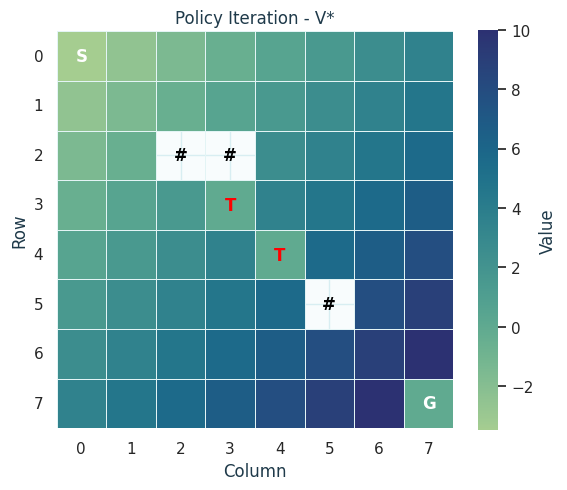

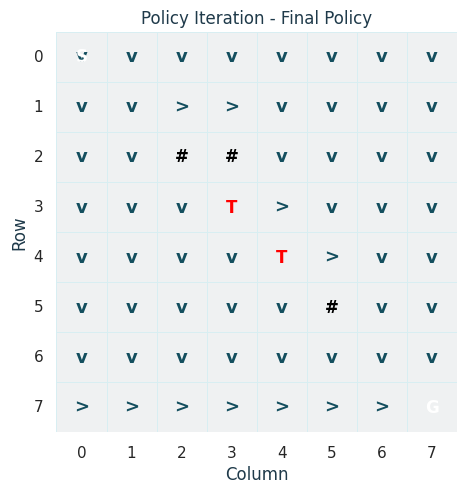

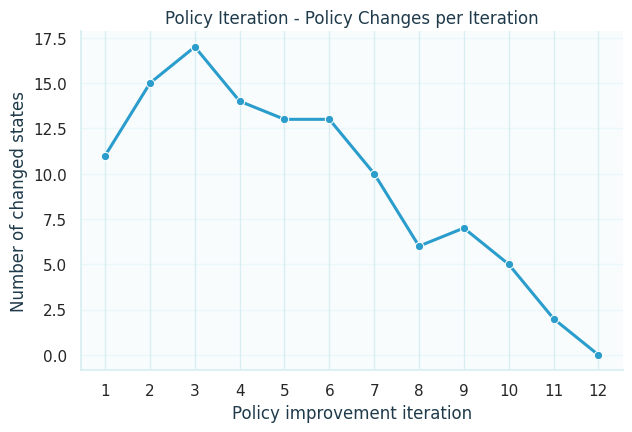

In [14]:
pi_value_path = NOTEBOOK_FIGURE_DIR / "policy_iteration_value_heatmap.png"
pi_policy_path = NOTEBOOK_FIGURE_DIR / "policy_iteration_policy.png"
pi_changes_path = NOTEBOOK_FIGURE_DIR / "policy_iteration_policy_changes.png"

plot_value_heatmap(
    pi_values,
    planning_env,
    "Policy Iteration - V*",
    save_path=pi_value_path,
    show=True,
)

plot_policy_arrows(
    pi_policy,
    planning_env,
    "Policy Iteration - Final Policy",
    save_path=pi_policy_path,
    show=True,
)

plot_policy_changes(
    pi_metrics["policy_changes_per_iteration"],
    title="Policy Iteration - Policy Changes per Iteration",
    save_path=pi_changes_path,
    show=True,
);

**Nhận xét kết quả Policy Iteration:**

Kết quả cho thấy `PolicyIteration` đã hội tụ thành công. Thuật toán dừng sau 12 vòng policy improvement, với trạng thái:

```python
policy_stable = True
```

và số state thay đổi action ở vòng cuối bằng:

$$
\Delta_{\pi, final} = 0
$$

Điều này nghĩa là policy không còn thay đổi sau bước improvement cuối cùng:

$$
\pi_{k+1}(s) = \pi_k(s), \quad \forall s \in \mathcal{S}
$$

Do đó, policy cuối cùng có thể xem là policy ổn định mà thuật toán tìm được.

So với Policy Evaluation, điểm khác biệt quan trọng là Policy Iteration không chỉ đánh giá một policy cố định. Thuật toán lặp lại hai bước:

1. Đánh giá policy hiện tại bằng Bellman Expectation Equation.
2. Cải thiện policy bằng cách chọn action tốt nhất tại mỗi state.

Quá trình này được thể hiện rõ qua biểu đồ **Policy Changes per Iteration**. Ban đầu số state thay đổi action còn lớn, nghĩa là policy vẫn đang được cải thiện mạnh. Về các iteration cuối, số state thay đổi giảm dần và cuối cùng bằng 0, cho thấy policy đã ổn định.

Value heatmap cho thấy các state gần Goal hoặc dễ dẫn tới Goal có giá trị cao hơn. Ngược lại, các state gần Trap hoặc bị ảnh hưởng bởi Wall có giá trị thấp hơn. Điều này phù hợp với trực giác của bài toán Grid-world: agent nên tìm đường tới Goal, tránh Trap và đi vòng qua Wall.

Biểu đồ **Final Policy** cho thấy hướng di chuyển mà agent chọn sau khi policy đã hội tụ. Các mũi tên nhìn chung hướng agent về vùng Goal, đồng thời tránh các ô Trap và Wall. Đây là kết quả hợp lý vì Policy Iteration đã sử dụng model đầy đủ của môi trường để tính expected return và cải thiện policy.

Tóm lại, Policy Iteration đã tìm được một policy ổn định thông qua quá trình evaluation-improvement. Kết quả này sẽ được dùng để so sánh với Value Iteration ở phần tiếp theo, vì cả hai thuật toán đều hướng tới nghiệm tối ưu của bài toán Planning.


## Value Iteration

**Mục tiêu:** tìm $V^*$ trực tiếp bằng Bellman Optimality Backup.

$$V_{k+1}(s)=\max_a\sum_{s'}P(s'\mid s,a)[r(s,a,s')+\gamma V_k(s')]$$

**Cơ chế:** khởi tạo value, lặp Bellman optimality backup, sau hội tụ trích xuất greedy policy.

Value Iteration đóng vai trò baseline cho SARSA/Q-learning và để so sánh với Policy Iteration/LP.

In [ ]:
value_iteration = ValueIteration(
    env=planning_env,
    theta=1e-6,
    max_iterations=1000,
    verbose=NOTEBOOK_VERBOSE,
    log_interval=NOTEBOOK_LOG_INTERVAL,
)

start_time = perf_counter()
vi_result = value_iteration.run()
vi_runtime = perf_counter() - start_time

vi_values = value_iteration.get_value_function()
vi_policy = value_iteration.get_policy()
vi_metrics = value_iteration.get_metrics()
vi_metrics["notebook_runtime_sec"] = vi_runtime

In [ ]:
show_metrics(vi_metrics, keys=[
    "status",
    "iterations",
    "final_bellman_residual",
    "bellman_backups",
    "notebook_runtime_sec",
])

print("Residual < theta:", vi_metrics["final_bellman_residual"] < vi_metrics["theta"])

In [ ]:
vi_value_path = NOTEBOOK_FIGURE_DIR / "value_iteration_value_heatmap.png"
vi_policy_path = NOTEBOOK_FIGURE_DIR / "value_iteration_policy.png"
vi_residual_path = NOTEBOOK_FIGURE_DIR / "value_iteration_residual.png"

plot_value_heatmap(
    vi_values,
    planning_env,
    "Value Iteration - V*",
    save_path=vi_value_path,
    show=True,
)

plot_policy_arrows(
    vi_policy,
    planning_env,
    "Value Iteration - Optimal Policy",
    save_path=vi_policy_path,
    show=True,
)

plot_bellman_residual(
    vi_metrics["bellman_residuals"],
    "Value Iteration Residual",
    save_path=vi_residual_path,
    show=True,
)

**Nhận xét cần điền sau khi chạy:**

- Value Iteration hội tụ sau bao nhiêu iterations?
- Heatmap $V^*$ phản ánh Goal/Trap/Wall như thế nào?
- Policy greedy có đường đi hợp lý đến Goal không?

## Linear Programming Planner

**Mục tiêu:** giải MDP bằng tối ưu tuyến tính.

Ràng buộc Bellman optimality:

$$V(s)\ge r(s,a)+\gamma\sum_{s'}P(s'\mid s,a)V(s')$$

Objective:

$$\min_V \sum_s V(s)$$

**Cơ chế:** tạo biến $V(s)$, tạo constraints cho state-action, giải LP, trích xuất policy từ nghiệm.

In [ ]:
lp_planner = LinearProgrammingPlanner(
    env=planning_env,
    verbose=1,
)

start_time = perf_counter()
lp_result = lp_planner.run()
lp_runtime = perf_counter() - start_time

lp_values = lp_planner.get_value_function()
lp_policy = lp_planner.get_policy()
lp_metrics = lp_planner.get_metrics()
lp_metrics["notebook_runtime_sec"] = lp_runtime

In [ ]:
show_metrics(lp_metrics, keys=[
    "status",
    "number_of_variables",
    "number_of_constraints",
    "solver_iter",
    "solver_iterations",
    "notebook_runtime_sec",
])

In [ ]:
lp_value_path = NOTEBOOK_FIGURE_DIR / "linear_programming_value_heatmap.png"
lp_policy_path = NOTEBOOK_FIGURE_DIR / "linear_programming_policy.png"

plot_value_heatmap(
    lp_values,
    planning_env,
    "Linear Programming - V*",
    save_path=lp_value_path,
    show=True,
)

plot_policy_arrows(
    lp_policy,
    planning_env,
    "Linear Programming - Derived Policy",
    save_path=lp_policy_path,
    show=True,
)

**Nhận xét cần điền sau khi chạy:**

- LP tạo bao nhiêu variables/constraints?
- Nghiệm LP gần Value Iteration ở mức nào?
- LP minh họa liên hệ giữa RL và Optimization ra sao?

## Đánh giá và so sánh Planning models

Cell dưới đây đánh giá trực tiếp từ các model vừa chạy, không phụ thuộc vào logs cũ.

In [ ]:
non_terminal_states = [state for state in planning_env.get_states() if not planning_env.is_terminal(state)]

planning_comparison = {
    "PI_vs_VI_inf_error": max_abs_error(pi_values, vi_values),
    "LP_vs_VI_inf_error": max_abs_error(lp_values, vi_values),
    "PI_vs_VI_mse": mean_squared_error(pi_values, vi_values),
    "LP_vs_VI_mse": mean_squared_error(lp_values, vi_values),
    "PI_vs_VI_policy_agreement": policy_agreement(pi_policy, vi_policy, non_terminal_states),
    "LP_vs_VI_policy_agreement": policy_agreement(lp_policy, vi_policy, non_terminal_states),
}

show_metrics(planning_comparison)

In [ ]:
comparison_error_path = NOTEBOOK_FIGURE_DIR / "planning_value_error_comparison.png"
comparison_agreement_path = NOTEBOOK_FIGURE_DIR / "planning_policy_agreement_comparison.png"

plot_comparison_bar(
    {
        "PI vs VI": planning_comparison["PI_vs_VI_inf_error"],
        "LP vs VI": planning_comparison["LP_vs_VI_inf_error"],
    },
    "Planning Value Error vs Value Iteration",
    save_path=comparison_error_path,
    ylabel="Infinity norm error",
    show=True,
)

plot_comparison_bar(
    {
        "PI vs VI": planning_comparison["PI_vs_VI_policy_agreement"],
        "LP vs VI": planning_comparison["LP_vs_VI_policy_agreement"],
    },
    "Planning Policy Agreement vs Value Iteration",
    save_path=comparison_agreement_path,
    ylabel="Agreement",
    show=True,
)

## Tổng kết Planning

Policy Evaluation là prediction/evaluation cho một policy cố định. Policy Iteration và Value Iteration tìm nghiệm tối ưu bằng Bellman equations. Linear Programming đưa bài toán MDP về optimization.

Trong notebook này, Value Iteration đóng vai trò baseline để so sánh PI và LP. Các kết quả cần nhận xét trong report gồm residual curves, value heatmap, policy arrows, agreement PI/LP với VI, runtime và Bellman backups.

TODO: Viết phần phân tích cuối cùng sau khi chạy toàn bộ notebook và chọn figures phù hợp cho báo cáo.